# Snippet - Regressão Lasso
A regressão lasso é um modelo linear que estima coeficientes esparsos. É útil em alguns contextos devido à sua tendência de preferir soluções com menos coeficientes diferentes de zero, reduzindo efetivamente o número de características das quais a solução dada depende. Por esse motivo, o Lasso e suas variantes são fundamentais para a área de sensoriamento comprimido. Sob certas condições, pode recuperar o conjunto exato de coeficientes diferentes de zero.

A função objetivo é descrita como: $min\frac{1}{2n}||Xw-y||^2 + \alpha ||w||$


In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model

In [2]:
# Data
data = {
    "x1": [1, 2, 3, 4, 5],
    "x2": [4, 8, 12, 16, 20],           # Relação linear com x1
    "x3": [7, 2, 5, 3, 6],              # Valores variados
    "x4": [3, 9, 27, 81, 243],          # Relação cúbica
    "x5": [9, 8, 6, 4, 1],              # Decrescente
    "y":  [18, 25, 40, 70, 130]         # Combinação linear + ruído
}

df = pd.DataFrame(data)

In [3]:
# Fit
lg = linear_model.Lasso(alpha=0.1)
lg.fit(df[["x1","x2","x3","x4","x5"]],df["y"])

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.544e+00, tolerance: 8.331e-01
  model = cd_fast.enet_coordinate_descent(


,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [4]:
# Attributes
print(f'Intercept: {lg.intercept_}\nCoeficients:{lg.coef_}')

Intercept: 56.046022257411266
Coeficients:[ 0.          0.43430396 -0.08597374  0.29118671 -4.53613318]


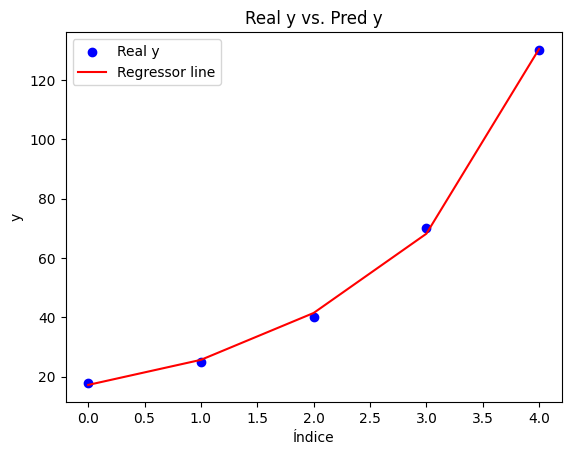

In [5]:
# Prep
X = df[["x1","x2","x3","x4","x5"]]
y = df["y"]
y_pred = lg.intercept_ + np.dot(X, lg.coef_)

# Viz
plt.scatter(range(len(y)), y, color='blue', label='Real y')
plt.plot(range(len(y_pred)), y_pred, color='red', label='Regressor line')
plt.xlabel('Índice')
plt.ylabel('y')
plt.legend()
plt.title('Real y vs. Pred y')
plt.show()